<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            Summer School for AstroStatistics in Sharjah 2025<br>
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

In [1]:
"""The Maximum Likelihood Estimation notebook."""


import requests

URL = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(URL, timeout=30).text
exec(colab)

URL = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
exec(requests.get(URL, timeout=30).text)

Repository:
https://github.com/AstroStat-Academy/astrostat-school-7.git

Branch:
main

Working in:
/content/astrostat-school-7/MLE

Content:
	 ['MLE.ipynb', 'data']
Imported matplotlib.
Imported seaborn.
Plotting style set.


# Maximum Likelihood Estimation


In [2]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import minimize
from IPython.display import display, HTML

# RR Lyrae stars in M4

RR Lyrae stars are variable pulsators that obey a precise period-luminosity relation. Here we have a sample of RR Lyrae stars in the globular cluster M4, observed with Spitzer by Neeley et al. (2015): https://ui.adsabs.harvard.edu/abs/2015ApJ...808...11N/abstract

Since the stars are at the same distance, then the apparent magnitude will also depend on the period:

$$ m = a\ {\rm log}\ P + b $$


In [3]:
RR_lyrae_table2 = Table.read('./data/table2.dat', readme='./data/ReadMe', format='cds')
RR_lyrae = RR_lyrae_table2[RR_lyrae_table2['Mode'] == 'RRab']

# Now remove sources V20 and V21 due to blending
RR_lyrae = RR_lyrae[RR_lyrae['ID'] != 'V20']
RR_lyrae = RR_lyrae[RR_lyrae['ID'] != 'V21']

print("Columns:", RR_lyrae.colnames)
logP, m36, e_m36 = RR_lyrae["logP"], RR_lyrae['[3.6]'], RR_lyrae['e_[3.6]']
logP, m36, e_m36 = logP[~m36.mask], m36[~m36.mask], e_m36[~m36.mask]

Columns: ['ID', 'RAh', 'RAm', 'RAs', 'DE-', 'DEd', 'DEm', 'DEs', 'Per', 'logP', '[3.6]', 'e_[3.6]', 'f_[3.6]', '[4.5]', 'e_[4.5]', 'f_[4.5]', '3.6amp', 'e_3.6amp', '4.5amp', 'e_4.5amp', 'Mode', 'f_Mode']


## RR Lyrae: The data

Let's plot the data from the 3.6μ band:


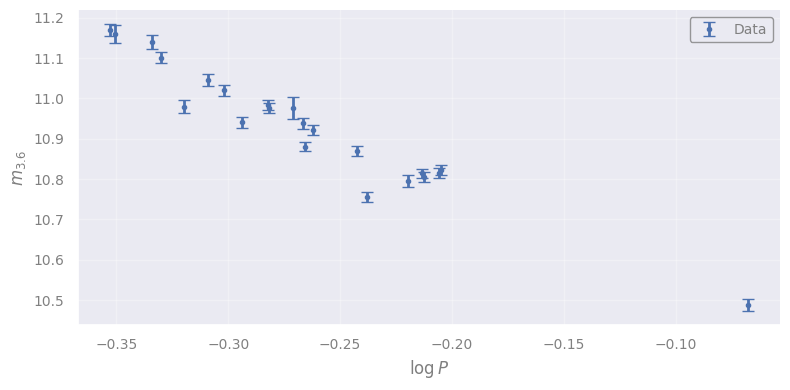

In [4]:
xx = np.linspace(np.min(logP), np.max(logP), 40)

plt.figure()
plt.errorbar(logP, m36, yerr=e_m36, fmt="b.", capsize=4, label="Data")
plt.legend(loc="upper right")
plt.xlabel(r"$\log P$")
plt.ylabel(r"$m_{3.6}$")
plt.show()

## Quick Python code for fitting

1. `numpy.polyfit` method for fitting polynomials

> It actually performs an ordinary least squares fit, obviously without taking into account the uncertainties

2. `scipy.optimize.minimize` can minimize any function

> ...so we can apply it to minimize the $\chi^2$ (using the uncertainties). Note that the optimization method is selected because it's not always successful

3. **A trick**

> $\chi^2$ fitting can be seen as a *weighted version* of ordinary least squares. The weights are applied on the unsquared residuals: $ w_i \left[y_i - \hat{y}(x_i)\right]$.
By comparing with the $\chi^2$ formula we can use $1/\sigma_i$ as weights in `numpy.polyfit` where $\sigma_i$ are the uncertainties of each data point.




> **Tasks:**
   
1. Make `np.polyfit` work
2. Select the initial guess for minimizing `chi_square`
3. Make `np.polyfit` work with the correct weights


Polyfit output:
[-2.369672   10.29960037]

Minimization output:
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 186.90598361947244
             x: [-2.338e+00  1.030e+01]
           nit: 34
          nfev: 66
 final_simplex: (array([[-2.338e+00,  1.030e+01],
                       [-2.338e+00,  1.030e+01],
                       [-2.338e+00,  1.030e+01]]), array([ 1.869e+02,  1.869e+02,  1.869e+02]))
Optimal Parameters:
[-2.33806527 10.30379998]

chi-square fitting using weighted polyfit:
[-2.33808939 10.30379338]


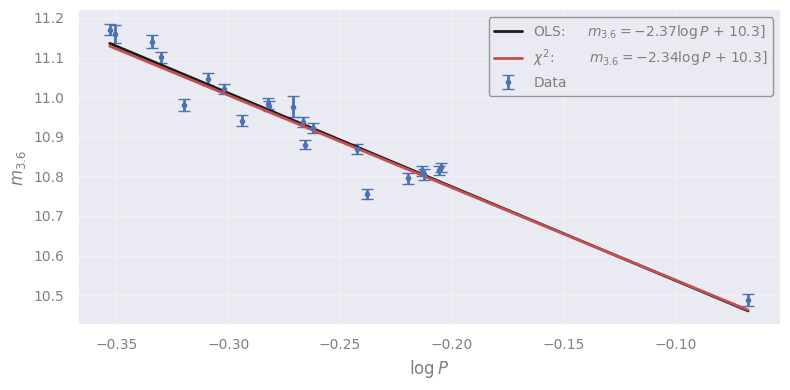

In [5]:
# ordinary least squares fit

ols_params = np.polyfit(logP, m36, deg=1)
print("Polyfit output:")
print(ols_params)
print()


# chi-square fitting using minimization

def chi_square(params):
    """Calculate the chi-square value for a given set of parameters."""
    slope_for_chi, intercept_for_chi = params
    m36_model = slope_for_chi * logP + intercept_for_chi
    return np.sum((m36 - m36_model) ** 2.0 / e_m36**2.0)

initial_estimate = ols_params       # use the OLS results as an initial estimate
min_result = minimize(chi_square, x0=initial_estimate, method="Nelder-Mead")
print("Minimization output:")
print(min_result)
print("Optimal Parameters:")
print(min_result.x)


# chi-square fitting using weighted OLS fit: w = 1/sigma here!

ch2_params = np.polyfit(logP, m36, deg=1, w=1.0/e_m36)
print()
print("chi-square fitting using weighted polyfit:")
print(ch2_params)


# plotting the results

OLS_LABEL = ("OLS:\t $m_{{3.6}} = "
             f"{ols_params[0]:.3g} \\log P$ + {ols_params[1]:.3g}]")
CHI_LABEL = ("$\\chi^2$:\t $m_{{3.6}} = "
             f"{ch2_params[0]:.3g} \\log P$ + {ch2_params[1]:.3g}]")
x_plot = np.linspace(np.min(logP), np.max(logP), 40)

plt.figure()
plt.errorbar(logP, m36, yerr=e_m36, fmt="b.", capsize=4, label="Data")
plt.plot(x_plot, np.polyval(ols_params, x_plot), "k-", lw=2, label=OLS_LABEL)
plt.plot(x_plot, np.polyval(ch2_params, x_plot), "r-", label=CHI_LABEL)
plt.legend(loc="upper right")
plt.xlabel(r"$\log P$")
plt.ylabel(r"$m_{3.6}$")
plt.show()

## Constructing a likelihood function

Our problem falls into the general case where we have a model connecting two quantities through a function with two parameters, $a$ and $b$: $y=f(x;a,b)=ax + b$.

In the general case, we use $\theta$ as a list of parameters: $\theta = \{\theta_1, \theta_2, \cdots, \theta_k\}$:

$$ \Large y = f(x; \theta) $$

Therefore, if we get $N$ data, $(x_i, y_i)$ for $i \in [1, 2, \cdots, N]$ based on the model we would expect:

$$\Large y_i = f(x_i; \theta) $$

However, all observations are **subject to uncertainty**, and we need to model this as well. More often than not, uncertainties are fluctuations of a certain magnitude $\sigma$ around 0, following the Gaussian distribution:

$$\Large y_i = f(x_i; \theta) + \epsilon_i $$

where $\epsilon_i$ is normally distributed:

$$\Large \epsilon_i \sim \mathrm{Norm}(0, \sigma_i)$$

The $\sigma_i$ is the standard deviation of the datum error distribution, or an **estimate** of the typical difference between the observed $y_i$ and the intrinsic, true value $y_i$ which we **assume that is described by the model**.

Consequently, according to our model, the probability to observe the $i$-th point's $y$-value given it's $x$-value, or the **datum likelihood** is

$$\Large
P(y_i | x_i) = \text{Norm}(y_i; f(\theta; x_i), \sigma_i)
   = \dfrac{1}{\sqrt{2\pi \sigma_i^2}} \exp \left[{-\dfrac{(y_i-f(x_i; \theta))^2}{2\sigma_i^2}} \right]
$$


Assuming that our measurements are independent (the probability of $y_2$ does not depend on $y_1$ or $x_3$), the overall probability to get our data, or **likelihood** (always **according to our model**) is the product of all likelihoods:

$$\Large L = P(y_1, y_2, \cdots, y_N | x_1, x_2, \cdots x_N) = \prod_{i=1}^{N} P(y_i | x_i)$$

Let's do the math...

$$\Large
L = \prod_{i=1}^{N} \dfrac{1}{\sqrt{2\pi \sigma_i^2}} \exp \left[{-\dfrac{(y_i-f(x_i))^2}{2\sigma_i^2}} \right]
$$

$$\Large
L = \left(\dfrac{1}{\sqrt{2\pi \sigma_i^2}}\right)^N \exp \left[ -\sum_{i=1}^{N} {\dfrac{(y_i-f(x_i))^2}{2\sigma_i^2}} \right]
$$

The parameters that maximize the likelihood are found by taking

$$\Large \frac{\partial L}{\partial a} = 0 \qquad\text{and}\qquad \Large \frac{\partial L}{\partial b} = 0$$


## The log trick

The likelihoods are typicall very small quantities. To avoid numerical issues, we are allowd to work in log-space (they are positive):

$$\Large
l = \ln{L} = -\frac{N}{2} \ln\left(2\pi \sigma^2\right) - \sum_{i=1}^{N} {\dfrac{(y_i-f(x_i))^2}{2\sigma_i^2}}
$$

Not only it simplifies the equation, but it's convenient for maximization with respect to any parameter $\theta_j$:

$$ \Large                      \frac{\partial \ln L}{\partial \theta_j}        = 0
   \quad\Leftrightarrow\quad   \frac{1}{L}\frac{\partial L}{\partial \theta_j} = 0
   \quad\Leftrightarrow\quad   \frac{\partial L}{\partial \theta_j}            = 0 $$

Therefore, for our example we can maximizing the log-likelihood with respect to the two parameters:

$$\Large \frac{\partial l}{\partial a} = 0 \qquad\text{and}\qquad \Large \frac{\partial l}{\partial b} = 0.$$


## Connection with $\chi^2$

The $l$ can be written as

$$\Large
l = \text{constant} - \frac{1}{2} \sum_{i=1}^{N} {\dfrac{(y_i-f(x_i))^2}{\sigma_i^2}} = \text{constant} - \frac{\chi^2}{2}
$$


Consequently, maximizing the likelihood is equivalent to minimizing the $\chi^2$!



## If the uncertainties are equal...

If $\sigma_i \equiv \sigma$, then...

$$\Large
l = \text{constant} - \frac{1}{2} \sum_{i=1}^{N} {\dfrac{(y_i-f(x_i))^2}{\sigma_i^2}} =
\text{constant} - \frac{1}{2\sigma^2} \sum_{i=1}^{N} {(y_i-f(x_i))^2}
$$


So maximizing the likelihood corresponds to minimizing the quantity

$$\Large \sum_{i=1}^{N} (y_i-f(x_i))^2 $$

...or the **sum of the squares**!

In fact, using $f(x) = a x + b$ you will arrive at the known OLS formulae for linear fitting without using linear algebra at all!


## Let's plot the likelihood close to the solution we found before


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Task**</font>
Complete the `log_likelihood` function.

</div>

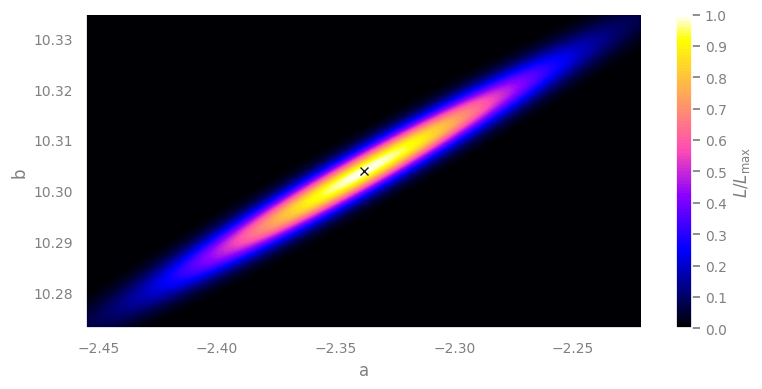

In [28]:
# construct a 2D grid with 101 points in each direction
a_grid = np.sort(np.linspace(0.95 * ch2_params[0], 1.05 * ch2_params[0], 101))
b_grid = np.sort(np.linspace(0.997 * ch2_params[1], 1.003 * ch2_params[1], 101))
[A, B] = np.meshgrid(a_grid, b_grid)


# construct the likelihood function (and vectorize it to be applied directly on arrays)
@np.vectorize
def log_likelihood(a, b):
    """The log-likelihood function for the linear model."""
    return -0.5*chi_square([a, b])
    # return -0.5*np.sum((m36 - (a * logP + b)) ** 2.0 / e_m36**2.0)

ln_like = log_likelihood(A, B)    # compute the likelihood in each grid point
ln_like = ln_like - np.max(ln_like)       # normalizing it for the maximum to be 0.0
L = np.exp(ln_like)               # un-log it to better visualization

# plot the results
plt.figure()
plt.contourf(A, B, L, 100, cmap='gnuplot2')
plt.plot(*ch2_params, "xk")
plt.xlabel("a")
plt.ylabel("b")
cbar = plt.colorbar(label=r"$L / L_{\max}$")
cbar.set_ticks(np.linspace(0, 1, 11))
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

As we saw above, the log-likelihood is connect to the $\chi^2$ term. Therefore,
we can use the function we created for this purpose:
<pre>
    return -0.5 * chi_square([a, b])
</pre>
  
</details>
</div>

# Exercise: fitting for slope only

Let's assume that in the above relation, the intercept $b$ is known (it mainly depends on the distance of the objects, and a calibration of the relation):

$$ m = a\ {\rm log}\ P + 10.3 $$


<u>**In-class discussion: Can we fit the slope using standard methods for fitting a line (OLS)?**</u>


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

We do not have an intercept any more. Even if we fit $m-10.3$, we might end up with a small "remainder".
Even if we take the logs again, we would have $\log(m-10.3) = \log a + \log\log P$ which requires fitting for the intercept only.
Perhaps, $a = (m - 10.3) / \log P$ is telling us that from each point we have an estimate of the slope and we could average them.
But none of these approaches takes into account the uncertainties.

</details>
</div>

In [ ]:
ols_params_1param = np.polyfit(logP, m36-10.3, deg=1)
a_1param, b_1param = ols_params_1param
print(f"Ordinary Least Squares result:     a={a_1param:.3f}, b={b_1param:.3g}")

slope_estimates = (m36-10.3) / logP
mean_slope = np.mean(slope_estimates)
print(f"Average of slope estimates:        a={mean_slope:.3f}")

In [ ]:
xx = np.linspace(np.min(logP), np.max(logP), 40)
plt.figure()
plt.errorbar(logP, m36, yerr=e_m36, fmt="b.", capsize=4, label="Data")
plt.plot(xx, 10.3 + np.polyval(ols_params_1param, xx), "k-", lw=2,
         label=f"OLS: $m_{{3.6}}$-10.3={a_1param:.3g} $\\log P$ {b_1param:.3g}")
plt.plot(xx, 10.3 + mean_slope * xx, "r-",
         label=f"$\\bar{{a}}$: $m_{{3.6}} - 10.3 = ${mean_slope:.3g} $\\log P$")
plt.legend(loc="upper right")
plt.xlabel(r"$\log P$")
plt.ylabel(r"$m_{3.6}$")
plt.show()

<u>**In-class discussion: Can we fit the slope using $\chi^2$-fitting?**</u>


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

<br>
    Sure! This includes the uncertainties, and we are using directly the likelihood we want.

</details>
</div>

In [ ]:
chi2_min_result = minimize(lambda a: np.sum((m36-10.3-a*logP)**2.0 / e_m36**2.0), x0=mean_slope)
print(f"Chi-square minimization estimate:  a={chi2_min_result.x[0]:.3f}")

<u>**In-class discussion: What is the uncertainty on the slope?**</u>


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

<br>
Most methods (OLS, $\chi^2$) have ways to get the uncertainties of the parameters. These are based on Gaussian approximations of the likelihood itself!
Here we have the likelihood, why not use it?

</details>
</div>

## Plotting the (log-)likelihood


In [ ]:
def log_likelihood_1param(slope):
    """The log-likelihood for a fit with fixed intercept at 10.3."""
    return -0.5*np.sum((m36-10.3 - slope*logP)**2.0 / e_m36**2.0)

# the slope values to try
a_values = a_grid.copy()

# the corresponding log-likelihood values
ln_like_values = np.array([log_likelihood_1param(a_value) for a_value in a_values])

# the likelihood values, normalized to 1
L_values = np.exp(ln_like_values - np.max(ln_like_values))


fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, figsize=(10, 3))

ax1.plot(a_values, ln_like_values, "k-")
ax2.plot(a_values, L_values, "k-")

ax1.set_ylabel(r"$\ln L$")
ax2.set_ylabel(r"$L$")
for ax in [ax1, ax2]:
    ax.set_xlabel("Slope, $a$")
plt.show()

## Estimating the uncertainty through the CDF

What does the *uncertainty on the slope* mean? The likelihood function gives all the information. Sigma values, upper and lower limits, are simply summarizing the likelihood using 1-2 values.

We can **define** as 68% confidence interval on the slope, the region around the median, where the area under the (properly normalized) likelihood is 68%:

$$\Large \int\limits_{lo}^{up} L(a) da = 0.68 $$

where $lo$ and $hi$ are the lower and upper bounds of the CI. Since we defined the CI as something around the median, this implies that the $lo$ and $up$ values correspond to the 16 and 84 percentiles. Therefore:

$$\Large \int\limits_{-\infty}^{lo} L(a) da = 0.16 $$

$$\Large \int\limits_{-\infty}^{up} L(a) da = 0.84 $$

This is why the **cumulative density function** (CDF) is very useful! We can obtain the CDF by integrating the likelihood:

$$\Large F(a') = \int\limits_{-\infty}^{a'} L(a) da $$

We have calculated $f(x)$ on a regular and fine grid of $x$: $\Delta x$ is constant and a small value. Consequently, the integral calculated in the same grid, is simply the **cumulative sum** of the likelihood values in the grid. Of course, we need to **normalize** it so that the CDF goes from 0 to 1 (- to +infinity). Since we started with a wide range of $x$ (including most of the area of the likelihood), we can assume that the CDF goes from 0 to 1 in our grid.

In [ ]:
cdf = np.cumsum(L_values)
cdf /= cdf[-1]

plt.figure()
plt.plot(a_values, cdf, "k.")
plt.xlabel("Slope, $a$")
plt.ylabel("Cumulative Distribution Function")
plt.show()

## Finding the confidence interval

The CDF calculated in the grid is a series of point. To find the value at which the CDF is say, 0.16, we can use interpolation! But not the typical one where we interpolate $y$ values from $x$ values, but the opposite!


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Task**</font>
Use interpolation to find the confidence interval and the median of the slope.

</div>

In [ ]:
lo68, median, hi68 = np.interp(..., ..., ...)
print(f"Slope = {median:.3f} +{hi68-median:.3f} -{median-lo68:.3f}")

plt.figure()
plt.axhspan(0.16, 0.84, facecolor="0.75", alpha=0.5, edgecolor="none")
plt.axvspan(lo68, hi68, facecolor="r", alpha=0.5, edgecolor="none")
plt.axvline(median, color="r")
plt.axhline(0.50, color="0.5", ls="-")
plt.plot(a_values, cdf, "k-")
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

We need to calculate the slope values ($a$ values) for which the CDF evaluates
to 0.16 (lower bound of the 68% confidence interval), 0.5 (median) and 0.84
(upper bound):
<pre>
lo68, median, hi68 = np.interp([0.16, 0.50, 0.84], cdf, a_values)
</pre>
  
</details>
</div>

## Additional considerations

1. The grid is not necessary. We can directly calculate any percentile by defining the CDF as a function that integrates (e.g., with `scipy.integrate`), and then using root finders or minimizers (e.g., with `scipy.optimize`), find the value for which it gives 0.16 or 0.84!

2. We can directly use the likelihood to calculate other statistics using formulas applied on distribution functions (don't forget to normalize your likelihood!):

Mean: $ \mu = \int\limits_{-\infty}^{+\infty} x L(x)\, dx$

Variance: $\text{Var} = \int\limits_{-\infty}^{+\infty} \left(x - \mu\right)^2 L(x) dx$

Standard deviation: $\sigma = \sqrt{\text{Var}}$

...and so on! It involves integrations that are typically easy to calculate with standard methods.


# Fitting a spectral line using MLE

Astrophysics loves spectra since extracting features from them is extremely informative regarding the physical processes of astronomical objects.

In this example we'll try to fit the LiI spectral line using a stellar spectrum.


In [ ]:
spectrum = np.load("data/lithium_line_example.npy")

fig, (ax_all, ax_zoom) = plt.subplots(1, 2, figsize=(12, 4))

ax_all.plot(spectrum['wavelength'], spectrum['flux'])
ax_zoom.errorbar(spectrum['wavelength'], spectrum['flux'],
                 yerr=spectrum['flux_error'], fmt='. ')

ax_zoom.set_xlim(6705, 6709)
ax_zoom.set_ylim(1200, 2700)

ax_all.set_title("All data")
ax_zoom.set_title("Zoomed in on the lithium line")
for ax in [ax_all, ax_zoom]:
    ax.set_xlabel(r'Wavelength ($\AA$)')
ax_all.set_ylabel('Counts')
plt.show()

### Let's focus on the lithium line


In [ ]:
lithium_line = spectrum[spectrum['wavelength'] > 6705]
lithium_line = lithium_line[lithium_line['wavelength'] < 6709]

plt.errorbar(lithium_line['wavelength'], lithium_line['flux'],
             yerr=lithium_line['flux_error'],
             fmt=' .')

plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Counts')

plt.show()

### Let's start by describing our model: a linear continuum plus a Gaussian absorption feature


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Tasks**</font>
1. Create the model: continuum + Gaussian line
2. Decide the return value of `ln_likelihood` for values outside the permitted ranges of the parameters
3. Complete the `ln_likelihood` function

</div>

In [ ]:
def model_flux(p, wavelength):
    """Return the flux for our model.

    Arguments
    ---------
    p : tuple
        The model parameters
    wavelength : float
        The input wavelength(s) at which we wish to calculate our model

    Returns
    -------
    flux : float
        The model flux(es) calculated by our model
    """
    # You can unpack the parameters if you want to use them by name
    # m, b, c, sigma, loc = p

    linear_part = m * (wavelength - 6707) + b
    gaussian_part = ...

    return linear_part + gaussian_part

def ln_likelihood(p, data):
    """Return the likelihood of our model.

    Arguments
    ---------
    p : tuple
        The model parameters
    data : ndarray
        The observed data from which we wish to calculate the likelihood of our model

    Returns
    -------
    ln_likelihood : float
        The log likelihood of our model
    """

    m, b, c, sigma, loc = p
    if sigma <= 0:
        return ...
    if loc < 6706 or loc > 6708:
        return ...

    # First, calculate the model fluxes at the observed wavelengths
    model_fluxes = model_flux(p, data['wavelength'])

    # Now capture our observed fluxes
    observed_fluxes = data['flux']
    observed_flux_errors = data['flux_error']

    # Compare the two
    ln_likelihood = ...

    return sum(ln_likelihood)

def neg_ln_likelihood(p, data):
    """Wrapper for ln_likelihood to return the negative of the log likelihood.

    Arguments
    ---------
    p : tuple
        The model parameters
    data : ndarray
        The observed data from which we wish to calculate the likelihood of our model

    Returns
    -------
    neg_ln_likelihood : float
        The negative of the log likelihood of our model
    """

    return -ln_likelihood(p, data)


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

In the model that describes the fluxes, we add a Gaussian absorption feature
(therefore we subtract the normalization factor `c`), the shape of which is
conveniently given by the `st.norm.pdf` function that takes as an input the
`x` values to be applied to, the location of the mean (`loc`), and the standard
deviation (`sigma`):
<pre>

    gaussian_part = -c * st.norm.pdf(wavelength, loc=loc, scale=sigma)
</pre>

In the log-likelihood function we treat "illegal values/ranges". The standard
deviation cannot be 0 or negative, or the location should be in the expected
range (to constrain the search to this line). In these cases, the likelihood
is 0, and therefore the log-likelihood is $-\infty$:
<pre>
    if sigma <= 0:
        return -np.inf
    if loc < 6706 or loc > 6708:
        return -np.inf
</pre>

Meanwhile, the overall likelihood function return the values expressed in the
equation we saw earlier: the constant term (can be omitted) containing the
flux errors, and the $\chi^2$ term that compares the observed fluxes with the
modeled ones:

<pre>
    ln_likelihood = (
        -np.log(observed_flux_errors * np.sqrt(2*np.pi))
        - (model_fluxes - observed_fluxes)**2 / (2 * observed_flux_errors**2)
        )
</pre>
  
</details>
</div>

### Let's start with a trial solution and use scipy minimize to find a solution


In [ ]:
INITIAL_M = 40
INITIAL_B = 2400
INITIAL_C = 400
INITIAL_SIGMA = 0.2
INITIAL_LOC = 6707.1

p0 = (INITIAL_M, INITIAL_B, INITIAL_C, INITIAL_SIGMA, INITIAL_LOC)

model_wavelengths = np.linspace(np.min(lithium_line['wavelength']),
                                np.max(lithium_line['wavelength']), 1000)
model_fluxes = model_flux(p0, model_wavelengths)

plt.plot(model_wavelengths, model_fluxes, color='C1')

plt.errorbar(lithium_line['wavelength'], lithium_line['flux'],
             yerr=lithium_line['flux_error'],
             fmt='.', capsize=2)

plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Counts')

plt.show()

In [ ]:
res = minimize(neg_ln_likelihood, p0, method='Nelder-Mead', args=lithium_line)
m_sol, b_sol, c_sol, sigma_sol, loc_sol = res.x
print(f"Best-fit parameters: m={m_sol:.3f}, b={b_sol:.3f}, c={c_sol:.3f}, "
      f"sigma={sigma_sol:.3f}, loc={loc_sol:.3f}")

best_p = res.x
model_wavelengths = np.linspace(np.min(lithium_line['wavelength']),
                                np.max(lithium_line['wavelength']), 1000)
model_fluxes = model_flux(best_p, model_wavelengths)

plt.figure()
plt.plot(model_wavelengths, model_fluxes, color='C1')
plt.errorbar(lithium_line['wavelength'], lithium_line['flux'],
             yerr=lithium_line['flux_error'],
             fmt='.', capsize=2)
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel('Counts')
plt.show()

### How does the likelihood vary with model parameters?

Let's see how the likelihood will vary with the the model parameters


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(12, 4), constrained_layout=True)
labels = ['m', 'b', 'c', r'$\sigma$', r'$\mu$']
width_perc = [0.8, 0.01, 0.1, 0.12, 0.000003]

for j, (label, ax) in enumerate(zip(labels, axes)):
    # get the best-fitting values
    trial_p = best_p.copy()

    # take a range around the j-th parameter's best-fiting value
    test_set = best_p[j] * np.linspace(1 - width_perc[j], 1 + width_perc[j], 1000)

    # get the log-likelihood for the different values (keeping fixed the rest of the parameters)
    ll = np.zeros_like(test_set)
    for i, test_val in enumerate(test_set):
        trial_p[j] = test_val
        ll[i] = ln_likelihood(trial_p, lithium_line)

    ax.plot(test_set, ll)
    ax.axvline(best_p[j], color='k', linestyle='dashed')
    ax.set_title(labels[j])
    ax.grid()

axes[0].set_ylabel(r'$\ln \mathcal{L}$')
plt.show()

In [ ]:
###EOF